                                            Лабораторна робота №1 “Зменшення розмірності даних”
                                                    Виконала Доля Анастасія КН-42-03
Мета: ознайомитися з основами зменшення розмірності даних (dimensionality reduction) на прикладі зображень рукописних цифр із набору MNIST. Навчитись виконувати метод головних компонент (PCA), інтерпретувати отримані результати, оцінювати втрату інформації після проєкції та реконструкції зображень.

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error

np.random.seed(123)

In [42]:
X, y = fetch_openml("mnist_784", version=1, return_X_y=True, as_frame=False)

print("X shape:", X.shape)         
print("y shape:", y.shape)
print("unique labels:", np.unique(y), "count:", len(np.unique(y)))

X shape: (70000, 784)
y shape: (70000,)
unique labels: ['0' '1' '2' '3' '4' '5' '6' '7' '8' '9'] count: 10


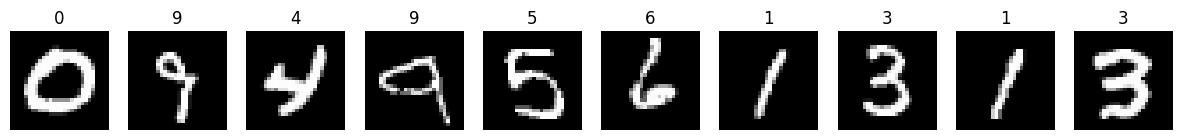

In [43]:
idx = np.random.choice(len(X), 10, replace=False)

fig, axes = plt.subplots(1, 10, figsize=(15, 3))

for ax, i in zip(axes, idx):
    ax.imshow(X[i].reshape(28, 28), cmap="gray")
    ax.set_title(str(y[i]))
    ax.axis("off")

plt.show()

завдання 2

Метод головних компонент (PCA) для зменшення розмірності даних MNIST з 784 до 3 компонент. Після трансформації кожне зображення представляється у вигляді тривимірного вектора (PC1, PC2, PC3). Перша компонента пояснює приблизно 9.7% дисперсії даних, друга — 7.1%, третя — 6.1%. Загальна пояснена дисперсія трьох компонент становить близько 23%, що означає значну втрату інформації при такому сильному зменшенні розмірності.

In [44]:
pca3 = PCA(n_components=3)

X_pca = pca3.fit_transform(X)

print("New form of data:", X_pca.shape)
print("Explained variance ratio:", pca3.explained_variance_ratio_)
print("Total explained variance:", pca3.explained_variance_ratio_.sum())

New form of data: (70000, 3)
Explained variance ratio: [0.09746116 0.07155445 0.06149531]
Total explained variance: 0.230510914900965


In [ ]:
import plotly.express as px
import plotly.io as pio
import numpy as np

pio.renderers.default = "notebook_connected"

X_small = X_pca[:70000]
y_small = y.astype(int)[:70000]

fig = px.scatter_3d(
    x=X_small[:, 0],
    y=X_small[:, 1],
    z=X_small[:, 2],
    color=y_small.astype(str),   
    opacity=0.6,
    title="MNIST in 3D PCA space (interactive)"
)

fig.update_traces(marker=dict(size=2))
fig.update_layout(
    scene=dict(
        xaxis_title="PC1",
        yaxis_title="PC2",
        zaxis_title="PC3"
    )
)

fig.show()

З графіка видно, що деякі цифри утворюють певні скупчення точок, однак між багатьма класами спостерігається перекривання. Це пояснюється тим, що метод PCA не використовує інформацію про класи і зберігає лише напрямки найбільшої дисперсії даних. Отже, тривимірне представлення дозволяє дослідити загальну структуру датасету та взаємне розташування класів, але не забезпечує повного розділення цифр.

Оцінимо те, наскільки добре 3-компонентне PCA-представлення зберігає інформацію, достатню для розпізнавання цифр. kNN-класифікатор у просторі (PC1, PC2, PC3) показав точність близько 0.49, що підтверджує: 3 компоненти зберігають частину структури класів, але через сильне перекривання у 3D повної відокремленості класів досягти неможливо.

In [46]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

X3 = X_pca
y_int = y.astype(int)

X_tr, X_te, y_tr, y_te = train_test_split(X3, y_int, test_size=0.2, random_state=42, stratify=y_int)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_tr, y_tr)
acc = knn.score(X_te, y_te)
print("kNN accuracy in 3D PCA:", acc)

kNN accuracy in 3D PCA: 0.48857142857142855


reconstruction

У цьому блоці виконано реконструкцію MNIST-зображень із 3-вимірного PCA-простору назад у початковий 784-вимірний простір пікселів за допомогою inverse_transform. Отримана форма (70000, 784) підтверджує повернення до початкової розмірності, але реконструкція є наближеною (через використання лише 3 компонент частина деталей зображення неминуче втрачається).

In [47]:
X_reconstructed = pca3.inverse_transform(X_pca)

print("Форма реконструйованих даних:", X_reconstructed.shape)

Форма реконструйованих даних: (70000, 784)


Виконаэмо візуальне порівняння оригінальних MNIST-зображень та їх реконструкції після зменшення розмірності методом PCA до трьох компонент. Для цього випадкові зображення було відображено у двох рядах: верхній містить оригінальні цифри, а нижній - реконструйовані зображення. 
Бачимо, що реконструйовані зображення зберігають загальну форму цифр, однак мають помітну втрату деталей та розмитість. 

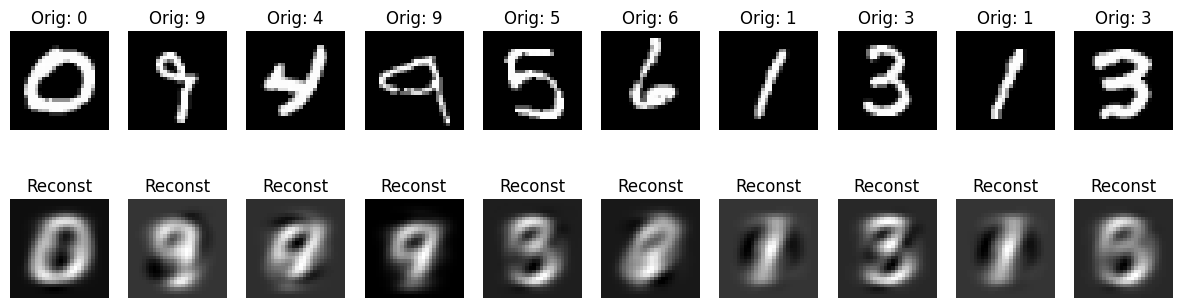

In [48]:
fig, axes = plt.subplots(2, 10, figsize=(15, 4))

for j, i in enumerate(idx):
    axes[0, j].imshow(X[i].reshape(28, 28), cmap="gray")
    axes[0, j].set_title(f"Orig: {y[i]}")
    axes[0, j].axis("off")
    
    axes[1, j].imshow(X_reconstructed[i].reshape(28, 28), cmap="gray")
    axes[1, j].set_title("Reconst")
    axes[1, j].axis("off")

plt.show()

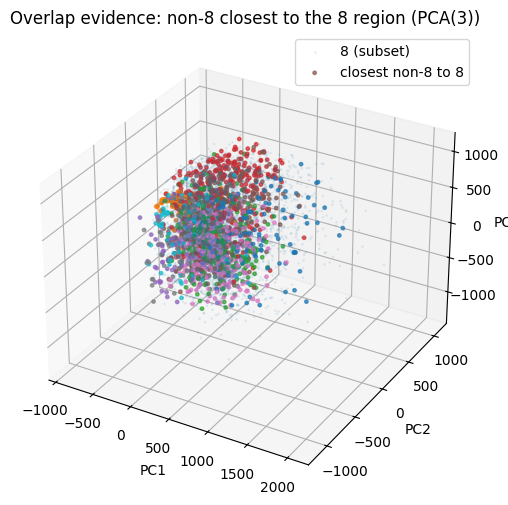

In [49]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors

y_int = y.astype(int)

X8 = X_pca[y_int == 8]
Xnot8 = X_pca[y_int != 8]
ynot8 = y_int[y_int != 8]

nn = NearestNeighbors(n_neighbors=1).fit(X8)
dist, _ = nn.kneighbors(Xnot8)

dist = dist.ravel()
N = 2000
idx = np.argsort(dist)[:N]   

X_close = Xnot8[idx]
y_close = ynot8[idx]

rng = np.random.default_rng(42)
idx8 = rng.choice(X8.shape[0], size=min(5000, X8.shape[0]), replace=False)
X8_plot = X8[idx8]

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(X8_plot[:,0], X8_plot[:,1], X8_plot[:,2],
           s=1, alpha=0.08, label="8 (subset)")

ax.scatter(X_close[:,0], X_close[:,1], X_close[:,2],
           c=y_close, cmap="tab10", s=6, alpha=0.7, label="closest non-8 to 8")

ax.set_title("Overlap evidence: non-8 closest to the 8 region (PCA(3))")
ax.set_xlabel("PC1"); ax.set_ylabel("PC2"); ax.set_zlabel("PC3")
ax.legend()
plt.show()

На графіку видно, що область розташування цифри 8 у просторі PCA(3) частково перекривається з іншими класами. Через це зразки інших цифр, які геометрично близькі до області 8, після реконструкції набувають подібних округлих форм. Це пояснюється тим, що при k=3 зберігаються лише глобальні варіації зображення, тоді як деталі, що відрізняють цифри, втрачаються. Тобто кожен колір - це інший клас.

Якщо точка цифри 3 або 9 знаходиться близько до області 8, її координати стають подібними до “типових” для 8, то при inverse_transform вона відновлюється на форму, яка візуально нагадує 8.

In [50]:
import numpy as np

y_int = y.astype(int)

center8 = X_pca[y_int == 8].mean(axis=0)

dist_to_8 = np.linalg.norm(X_pca - center8, axis=1)

N = 2000
mask_not8 = (y_int != 8)

idx_not8_all = np.where(mask_not8)[0]

dist_not8 = dist_to_8[idx_not8_all]

near_pos = np.argsort(dist_not8)[:N]

idx_not8 = idx_not8_all[near_pos]

unique, counts = np.unique(y_int[idx_not8], return_counts=True)

order = np.argsort(-counts)
unique = unique[order]
counts = counts[order]

for u, c in zip(unique, counts):
    print(f"Digit {u}: {c}")

Digit 6: 641
Digit 2: 580
Digit 5: 393
Digit 3: 257
Digit 0: 85
Digit 1: 22
Digit 7: 10
Digit 9: 7
Digit 4: 5


Бачимо серед НЕ-8, які найближчі до області 8 в PCA(3). Явно видно домінування 6, 2, 5, 3. PCA(3) розміщує 6, 2, 5 найближче до області 8. Після реконструкції багато цифр ставали схожими на 8.
Бо їхні PCA-координати лежать близько до області 8 - реконструкція відновлює усереднену округлу структуру.

5

In [51]:
components = range(1, 101)

mse_list = []
var_list = []

for k in components:
    pca = PCA(n_components=k)
    X_k = pca.fit_transform(X)
    X_rec = pca.inverse_transform(X_k)
    
    mse = mean_squared_error(X, X_rec)
    mse_list.append(mse)
    
    var_list.append(pca.explained_variance_ratio_.sum())
for k, mse, var in zip(components, mse_list, var_list):
    print(f"{k:3d} | MSE: {mse:8.2f} | Var: {var:.4f}")

  1 | MSE:  3948.58 | Var: 0.0975
  2 | MSE:  3635.53 | Var: 0.1690
  3 | MSE:  3366.49 | Var: 0.2305
  4 | MSE:  3130.09 | Var: 0.2845
  5 | MSE:  2916.20 | Var: 0.3334
  6 | MSE:  2727.85 | Var: 0.3765
  7 | MSE:  2584.43 | Var: 0.4093
  8 | MSE:  2458.01 | Var: 0.4382
  9 | MSE:  2337.33 | Var: 0.4657
 10 | MSE:  2234.86 | Var: 0.4892
 11 | MSE:  2142.70 | Var: 0.5102
 12 | MSE:  2053.55 | Var: 0.5306
 13 | MSE:  1978.87 | Var: 0.5477
 14 | MSE:  1904.76 | Var: 0.5646
 15 | MSE:  1835.48 | Var: 0.5805
 16 | MSE:  1770.46 | Var: 0.5953
 17 | MSE:  1712.74 | Var: 0.6085
 18 | MSE:  1656.78 | Var: 0.6213
 19 | MSE:  1604.84 | Var: 0.6332
 20 | MSE:  1554.40 | Var: 0.6447
 21 | MSE:  1507.76 | Var: 0.6554
 22 | MSE:  1463.58 | Var: 0.6655
 23 | MSE:  1421.62 | Var: 0.6751
 24 | MSE:  1381.82 | Var: 0.6842
 25 | MSE:  1343.18 | Var: 0.6930
 26 | MSE:  1306.48 | Var: 0.7014
 27 | MSE:  1271.05 | Var: 0.7095
 28 | MSE:  1236.67 | Var: 0.7173
 29 | MSE:  1204.29 | Var: 0.7247
 30 | MSE:  11

In [56]:
components = np.array(list(components))
mse_arr = np.array(mse_list)
var_arr = np.array(var_list)

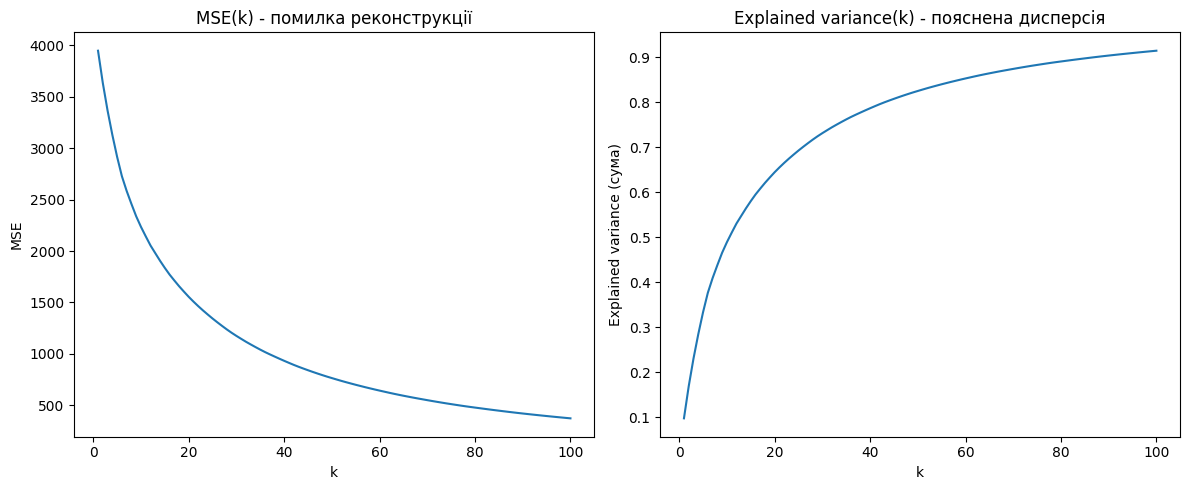

In [53]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(components, mse_arr)
plt.xlabel("k")
plt.ylabel("MSE")
plt.title("MSE(k) - помилка реконструкції")

plt.subplot(1,2,2)
plt.plot(components, var_arr)
plt.xlabel("k")
plt.ylabel("Explained variance (сума)")
plt.title("Explained variance(k) - пояснена дисперсія")

plt.tight_layout()
plt.show()

Досліджено вплив кількості головних компонент PCA на якість реконструкції даних. Побудовані графіки показують, що зі збільшенням кількості компонент помилка реконструкції (MSE) швидко зменшується, а частка поясненої дисперсії зростає. Приблизно після 50–60 компонент приріст поясненої дисперсії стає повільнішим, що свідчить про те, що основна інформація даних уже збережена. Так, PCA дозволяє значно зменшити розмірність даних, зберігаючи при цьому більшу частину їх структури.

In [54]:
k90 = components[np.argmax(var_arr >= 0.90)]
print("k for 90% variance:", k90)

k for 90% variance: 87


In [55]:
if np.any(var_arr >= 0.95):
    k95 = components[np.argmax(var_arr >= 0.95)]
    print("k for 95% variance:", k95)
else:
    print("95% variance is NOT reached up to k=100")

95% variance is NOT reached up to k=100


У цьому блоці було визначено мінімальну кількість головних компонент PCA, необхідних для збереження певної частки інформації даних. Бачимо, що для збереження 90% поясненої дисперсії потрібно приблизно 87 компонент. Водночас навіть при використанні 100 компонент рівень 95% поясненої дисперсії не досягається. Це свідчить про те, що інформація у наборі MNIST розподілена між великою кількістю ознак, і для її майже повного збереження необхідна значна кількість компонент.